# Back-projecting a tsunami source: non-dispersive walkthrough

**Event:** 2025-07-30 M8.8 Kamchatka earthquake &nbsp;&bull;&nbsp; **Package:** `tsbp` (uses `TsunamiTrace` for the ray tracing)

SWOT flew over the North Pacific about an hour after the earthquake and imaged the
tsunami as a set of sea-surface-height crests. Given the *shape* and *arrival time*
of one of those crests, **where did it come from?** That is the back-projection
question this package answers: it fans rays backwards from the observed wavefront,
across real bathymetry, and scores every candidate source location by how well its
predicted wavefront matches what SWOT saw.

This notebook walks through the simplest case end to end: three **unfiltered** crests
treated as long (shallow-water) waves, `c = sqrt(g*h)`, with **no dispersion**. It uses
the self-contained config [`non-dispersive-demo.yaml`](non-dispersive-demo.yaml) and
the small bundled data in [`data/`](data). Everything here runs from a fresh clone,
with no external DEM or SWOT downloads.

> The dispersive counterpart (band-passed crests, in-situ wavelength, source
> bootstrap) is `configs/bandpass_40_50.yaml`. Start here first.

## 1. Setup

Jupyter runs a notebook with the working directory set to the notebook's folder, so
the config's relative paths (`data/...`, `output/`) resolve as-is. We just confirm the
bundled data is visible and `tsbp` is importable.

In [1]:
import os, sys, subprocess, textwrap
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
from IPython.display import Image, display

import tsbp
from tsbp.config import load_config
from tsbp.io import load_domain_bathymetry, load_wf_polyline, load_swot_ssh

assert Path("data").is_dir(), "run this notebook from the examples/ directory"
print("tsbp", tsbp.__version__, "| data files:",
      sorted(p.name for p in Path("data").iterdir()))

tsbp 0.1.0 | data files: ['bandpass_40_50_0.geojson', 'bandpass_40_50_1.geojson', 'bandpass_40_50_2.geojson', 'bandpass_40_50_3.geojson', 'bandpass_40_50_4.geojson', 'bandpass_40_50_5.geojson', 'bandpass_40_50_6.geojson', 'bandpass_40_50_7.geojson', 'bandpass_40_50_8.geojson', 'bandpass_40_50_9.geojson', 'etopo2_kamchatka.nc', 'swot_ssh.txt', 'swot_times.csv', 'unfiltered_0.geojson', 'unfiltered_1.geojson', 'unfiltered_2.geojson']


## 2. The bundled inputs

Everything the run needs is a small subset of the full paper data (about 2 MB total):

| file | what it is |
|------|------------|
| `data/etopo2_kamchatka.nc` | ETOPO2v2c bathymetry, cropped to 150-170 E, 41-55 N (the ray-tracing domain) |
| `data/unfiltered_{0,1,2}.geojson` | three SWOT-digitised wavefront crests (lon/lat polylines) |
| `data/swot_times.csv` | per-pixel SWOT sampling time (SWOT images each pixel at a slightly different time) |
| `data/swot_ssh.txt` | the observed SSH anomaly field, used only for the background of the result plots |

Let's load the bathymetry and the three crests and see the geometry we are working
with. The crests sit far to the SE of the epicentre, out where SWOT caught them.

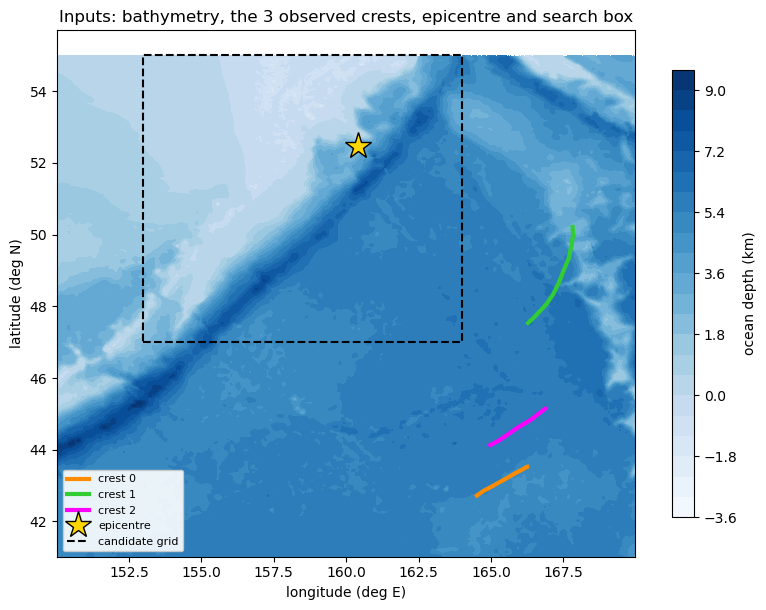

In [2]:
cfg = load_config("non-dispersive-demo.yaml")

blon, blat, depth = load_domain_bathymetry(cfg)          # depth (n_lon, n_lat), ocean +ve
fronts = [load_wf_polyline(w.path) for w in cfg.wavefronts]

# warm, non-blue colours so the crests read clearly over the blue bathymetry
crest_colors = ["darkorange", "limegreen", "magenta"]

fig, ax = plt.subplots(figsize=(8, 6.2))
cf = ax.contourf(blon, blat, depth.T / 1000.0, levels=20, cmap="Blues")
plt.colorbar(cf, ax=ax, label="ocean depth (km)", shrink=0.85)

for w, pts, col in zip(cfg.wavefronts, fronts, crest_colors):
    ax.plot(pts[:, 0], pts[:, 1], "-", lw=3, color=col, label=f"crest {w.name}")
ax.plot(cfg.epi_lon, cfg.epi_lat, "*", ms=20, mec="k", mfc="gold", label="epicentre")

# candidate-source search box
cl, ct = cfg.cand_lon, cfg.cand_lat
ax.plot([cl[0], cl[1], cl[1], cl[0], cl[0]], [ct[0], ct[0], ct[1], ct[1], ct[0]],
        "k--", lw=1.5, label="candidate grid")

ax.set(xlabel="longitude (deg E)", ylabel="latitude (deg N)",
       title="Inputs: bathymetry, the 3 observed crests, epicentre and search box")
ax.legend(loc="lower left", fontsize=8, framealpha=0.9)
plt.tight_layout()

The crests are hundreds of km SE of the epicentre. A **single** far-field crest only
constrains an *arc* of possible sources (many source points share the same travel
time to that crest), which is exactly why we back-project several crests
independently and compare: their arcs intersect near the true source region.

## 3. The config, section by section

A run is fully described by one YAML file. Here it is, annotated:

In [3]:
print(Path("non-dispersive-demo.yaml").read_text())

# Self-contained back-projection demo: 2025-07-30 M8.8 Kamchatka earthquake.
#
# This is the RUNNABLE twin of ../configs/non-dispersive-demo.yaml: identical
# physics, but every path points at the small bundled subsets in ./data/ so the
# example runs straight from a fresh clone (no external DEM / SWOT downloads).
# It is intended to be run from THIS directory (examples/):
#
#     cd examples
#     tsbp --config non-dispersive-demo.yaml
#
# wavelength: null  =>  shallow-water c = sqrt(g*h), no dispersion.

event:
  epi_lon: 160.396
  epi_lat: 52.473
  origin_time_utc: "2025-07-30T23:24:52"
  rupture_speed_kms: 2.2

bathymetry:
  path: data/etopo2_kamchatka.nc     # ETOPO2v2c subset to the domain below
  negate: true                       # DEM stores ocean negative -> flip to positive
  domain_lon: [150.0, 170.0]
  domain_lat: [41.0, 55.0]

swot:
  times: data/swot_times.csv         # per-pixel SWOT sampling times (time,lat,lon)
  ssh: data/swot_ssh.txt             # observed SSH anoma

What each block does:

- **`event`**: epicentre, origin time, and rupture speed (2.2 km/s). The rupture speed
  adds the time for the rupture to travel from the epicentre to each candidate source;
  it only affects the *anchored* map.
- **`bathymetry`**: the DEM and the domain window rays are traced in. `negate: true`
  flips the DEM's ocean-negative convention to the ocean-positive one the tracer wants.
- **`swot`**: the observed timing. `times` gives each crest point its per-pixel SWOT
  arrival time (the real anchor); `ssh` is only for the plot background.
- **`candidate`**: the grid of trial source locations (0.1 deg) that get scored.
- **`tracing`**: integration step, max time, ray-fan width and spacing, and the output
  bin size. `azimuth_step_deg: 0.05` is a dense fan (slower but smooth misfit maps).
- **`time_search`**: an independent hypothesis. Instead of using the rupture delay,
  sweep a single *emission time* tau and find the best (place, tau) jointly.
- **`wavefronts`**: the crests, each back-projected **independently**. `wavelength:
  null` selects the shallow-water long-wave speed (this is the non-dispersive demo).

## 4. Run it

This traces about 1e5 rays per crest for all three crests, so it takes **about 2
minutes**. We call `tsbp` as a module through the *same* Python that runs this
notebook, so it uses this environment's install. Output lands in `output/`
(git-ignored).

In [4]:
subprocess.run([sys.executable, "-m", "tsbp", "--config", "non-dispersive-demo.yaml"],
               check=True,
               stderr=subprocess.DEVNULL)  # hide per-point progress bars; reports still stream

Wavefronts to back-project: ['0', '1', '2']
Loading + subsetting bathymetry ...
  domain 150.0..170.0 E, 41.0..55.0 N -> depth (600, 420)
  candidate grid 111 x 81 cells

========== wavefront: nd_0 ==========
Loading WF polyline ...
  60 WF points (resampled from 8), lon 164.51..166.25, lat 42.72..43.53
Matching SWOT per-pixel times: data/swot_times.csv
  per-pixel arrival 68.95..69.26 min (mean 69.11); nearest-pixel match 0.2..2.0 km
Raw coverage diagnostic (fill=False) ...

--- forward consistency (trace FROM configured epicentre) ---
  model travel time epicentre -> WF: 77.2..80.8 min, mean 78.87 min
  observed (anchor) arrival times:    69.0..69.3 min, mean 69.11 min
  gap (model - observed):             mean +9.76 min, range +8.00..+11.80  <-- INCONSISTENT
  => the anchored arc will sit off the epicentre by this much in travel time;
     reconcile the epicentre / arrival times / wave-speed model before trusting
     the absolute anchored location.
Back-projecting (wave=shallow-wat

CompletedProcess(args=['/Users/dmelgarm/opt/anaconda3/envs/tsunamitrace/bin/python', '-m', 'tsbp', '--config', 'non-dispersive-demo.yaml'], returncode=0)

## 5. Results

Each crest writes its own misfit maps (`_anchored`, `_free`, `_geom`), a coverage
diagnostic, an emission-time search, and a wavefront-fit figure, plus `.npz` and `.nc`
grids. `nd_summary.csv` and `nd_compare.png` summarise all three together.

**The per-crest best-fit source locations:**

In [5]:
summary = pd.read_csv("output/nd_summary.csv")
summary

,wavefront,wavelength_m,n_points,anc_lon,anc_lat,anc_misfit_min,anc_offset_km,anc_valley_ew_km,anc_valley_ns_km,anc_resid_min,geom_lon,geom_lat,geom_misfit_min,geom_offset_km,free_lon,free_lat,free_misfit_min,free_offset_km
0,0,shallow,60,157.8,49.8,0.159,348.0,392.0,411.0,-0.023,160.3,48.4,0.093,452.9,160.6,48.0,0.109,497.6
1,1,shallow,60,157.5,51.1,0.726,250.9,98.0,133.0,0.449,158.9,51.0,0.171,193.5,158.4,50.9,0.223,222.5
2,2,shallow,60,157.5,50.5,0.259,297.2,392.0,489.0,0.068,158.9,50.1,0.108,283.6,158.4,50.0,0.107,308.1


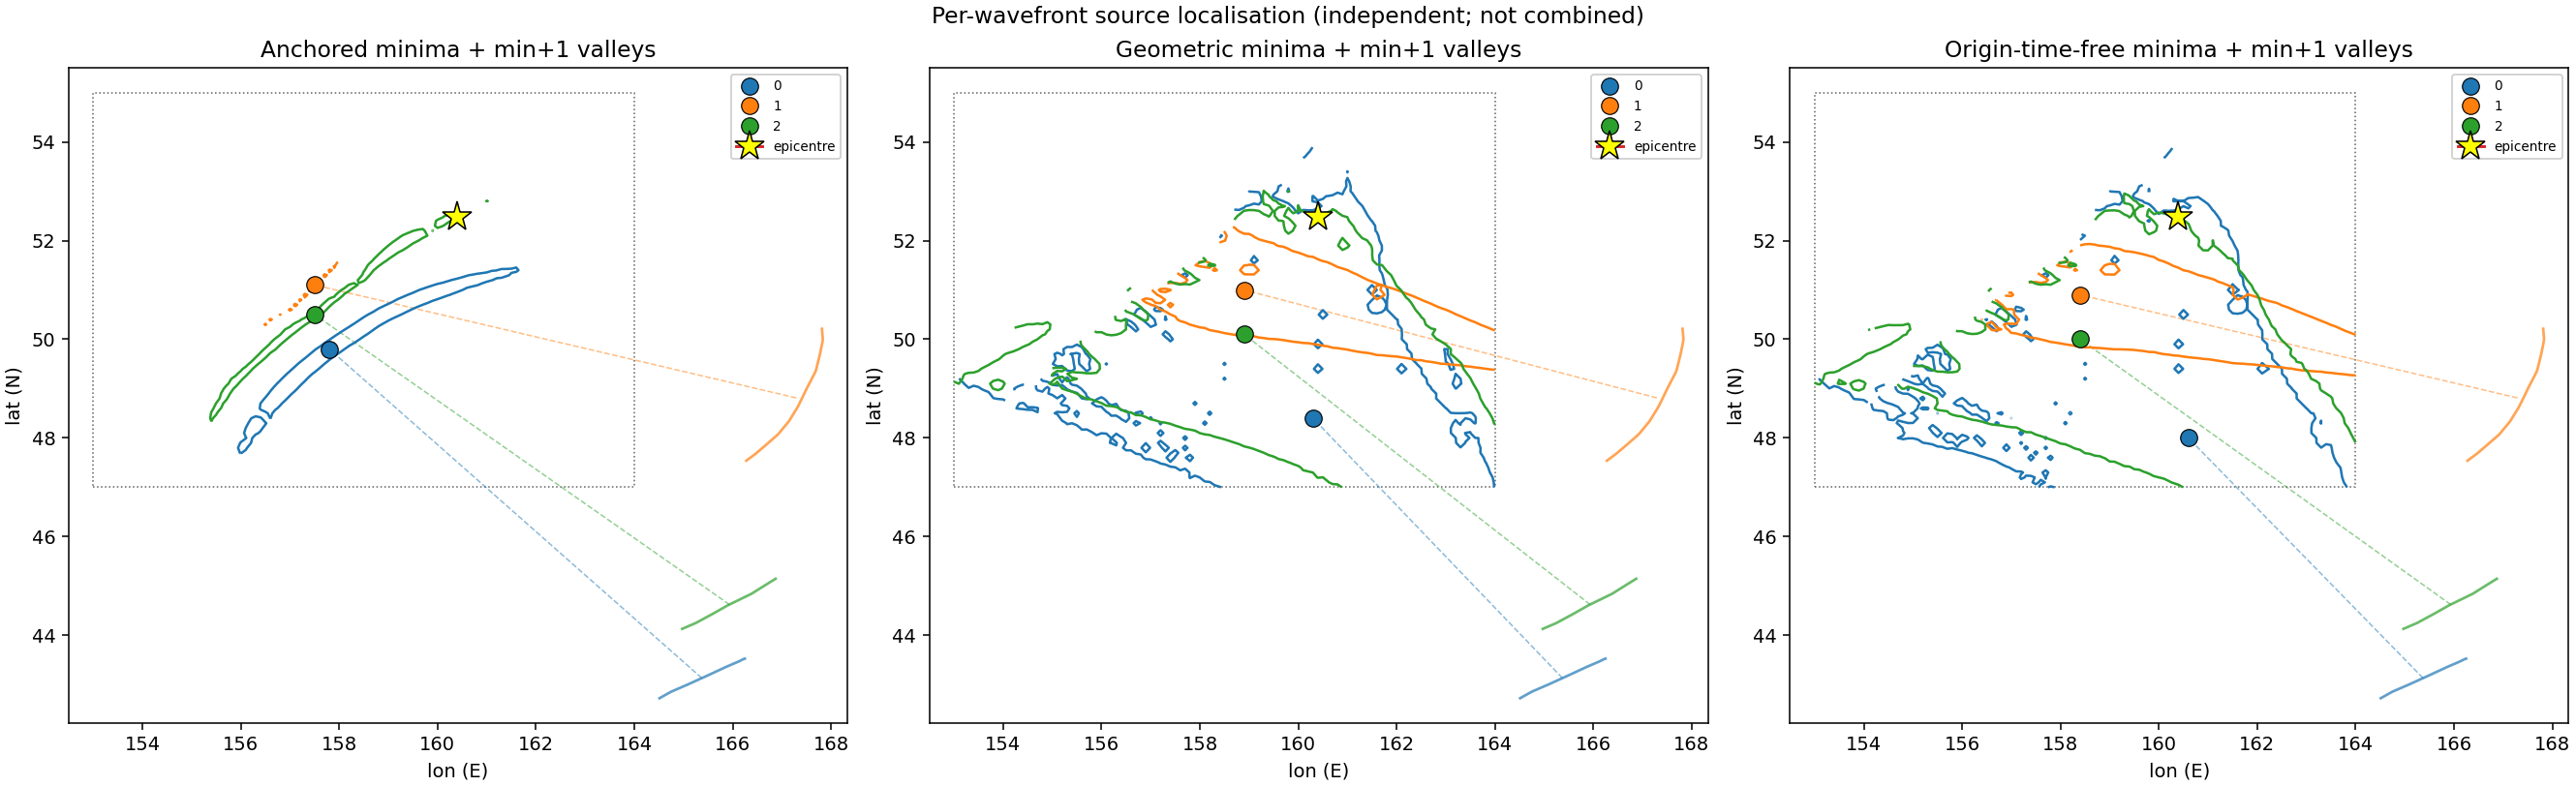

In [6]:
display(Image(filename="output/nd_compare.png"))

### Working with the raw output

The maps are also saved as arrays, so you can plot or post-process them yourself.
Here is crest **1** (the best-constrained one), its *anchored* misfit in minutes,
with its own crest and the epicentre. Dark means source locations whose predicted
wavefront best matches the observed arrival.

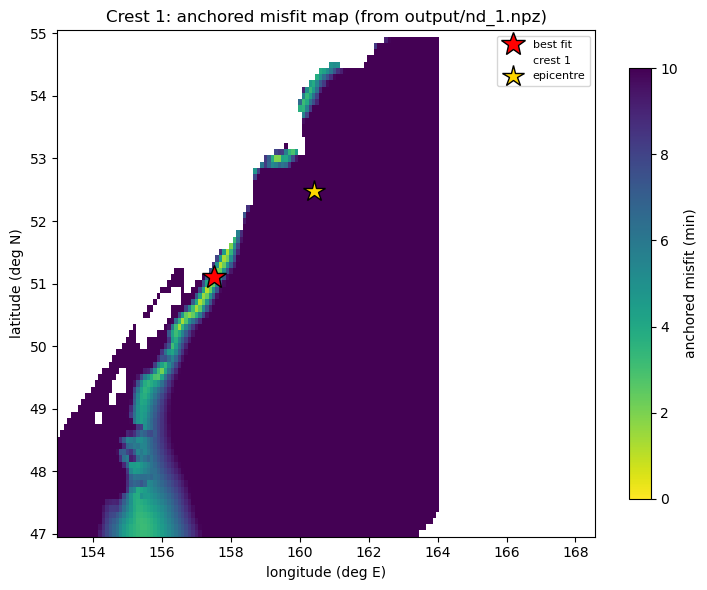

In [7]:
d = np.load("output/nd_1.npz")
clon, clat, rms = d["clon"], d["clat"], d["rms_anchored"]

fig, ax = plt.subplots(figsize=(7.5, 6))
pc = ax.pcolormesh(clon, clat, rms, cmap="viridis_r", vmin=0, vmax=cfg.misfit_vmax,
                   shading="auto")
plt.colorbar(pc, ax=ax, label="anchored misfit (min)", shrink=0.85)

jmin = np.unravel_index(np.nanargmin(rms), rms.shape)
ax.plot(clon[jmin[1]], clat[jmin[0]], "r*", ms=18, mec="k", label="best fit")
ax.plot(fronts[1][:, 0], fronts[1][:, 1], "w-", lw=2.5, label="crest 1")
ax.plot(cfg.epi_lon, cfg.epi_lat, "k*", ms=16, mfc="gold", label="epicentre")
ax.set(xlabel="longitude (deg E)", ylabel="latitude (deg N)",
       title="Crest 1: anchored misfit map (from output/nd_1.npz)")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()

## 6. How to read the maps

- **The elongated low-misfit valley** is the arc degeneracy: one far-field crest
  cannot pin a point, only a curve of equally-good sources. Overlapping the three
  crests' valleys (the `nd_compare` figure) is what localises the source.
- **Three different misfit maps** are written per crest:
  - **anchored**: uses the observed per-pixel arrival *times* and the rupture delay.
  - **free** (origin-time-free): marginalises out the absolute timing; robust when the
    emission time is uncertain (relevant for later, dispersed crests).
  - **geom**: pure geometry, ignores timing entirely.
- **The emission-time search** (`nd_*_timesearch.png`) is the separate hypothesis from
  section 3: best (location, tau) with the rupture delay switched off.

See the top-level `README.md` for the full definitions of the anchored, free, and geom
misfits and the physics behind the ray tracing.

## 7. Next steps

- **Full-resolution paper run:** `configs/non-dispersive-demo.yaml` is the same
  physics pointed at the complete DEM and SWOT data (the author's local paths).
- **Dispersion:** `configs/bandpass_40_50.yaml` back-projects band-passed crests as
  *dispersive* waves (in-situ wavelength via `local_wavelength`, plus a source
  bootstrap for uncertainty). The [`bandpass-40-50-dispersive.ipynb`](bandpass-40-50-dispersive.ipynb)
  notebook walks through it.
- **Your own event:** copy this YAML, point `bathymetry`, `swot`, and `wavefronts` at
  your data, and adjust the `candidate` box and `event` block. Nothing here is
  Kamchatka-specific except the numbers in the config.